# Notebook 15 — D7 R_e-source systematic at the WIDE window (Task 5, 2026-06-08)

D7 (TESTS) quantifies σ_e sensitivity to *which* R_e estimator sets the aperture. Measured at the
**narrow** window (spread 16.9 km/s → ±8.45) and never re-measured at the wide arc-masked window that
drives the headline, so it is **not folded into the M11 wide budget**. This notebook re-measures it on
the headline pipeline, varying only the aperture r_max over the four R_e estimators
(mean=2.305", F140W, F200LP, CaHK+G), everything else fixed.

Driver `scripts/run_sigma_e_Re_systematic_wide.py` → `results/sigma_e_Re_systematic_wide_N500.npz`.
See also notebook 14 (R_e family / CoG reconciliation).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os,sys,numpy as np,matplotlib.pyplot as plt
from pathlib import Path
_p=Path.cwd(); REPO=_p.parent if _p.name=='notebooks' else _p
os.chdir(REPO); sys.path.insert(0,str(REPO))
N=500; d=np.load(f'results/sigma_e_Re_systematic_wide_N{N}.npz',allow_pickle=True)
labels=list(d['labels']); Re=d['R_e']; p50=d['p50']; lo=d['stat_lo']; hi=d['stat_hi']; nk=d['n_kept']
pk2pk=float(d['peak_to_peak']); sys_re=float(d['sys_re']); mean_p50=float(d['mean_p50'])
print(f'{"R_e source":10s} {"R_e":>7s} {"n_kept":>7s} {"sig_e":>8s} {"D vs mean":>10s}')
print('-'*48)
for i,l in enumerate(labels):
    print(f'{l:10s} {Re[i]:>7.3f} {nk[i]:>7d} {p50[i]:>8.2f} {p50[i]-mean_p50:>+10.2f}')
print('-'*48)
print(f'peak-to-peak={pk2pk:.2f}  ->  D7(wide)=+-{sys_re:.2f} km/s   [D7(narrow) was +-8.45]')

R_e source     R_e  n_kept    sig_e  D vs mean
------------------------------------------------
mean         2.305     146   269.62      +0.00
F140W        2.168     128   267.44      -2.18
F200LP       2.441     167   272.44      +2.81
CaHK_G       2.902     237   279.69     +10.07
------------------------------------------------
peak-to-peak=12.25  ->  D7(wide)=+-6.13 km/s   [D7(narrow) was +-8.45]


saved results/figures/nb15_Re_systematic_wide.png


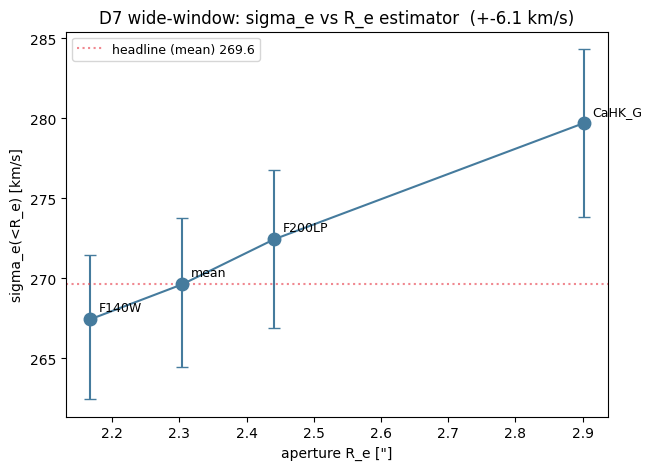

In [2]:
fig,ax=plt.subplots(figsize=(7,5))
order=np.argsort(Re)
ax.errorbar(Re[order],p50[order],yerr=[lo[order],hi[order]],fmt='o-',ms=9,capsize=4,color='#457b9d')
for i in order:
    ax.annotate(labels[i],(Re[i],p50[i]),textcoords='offset points',xytext=(6,6),fontsize=9)
ax.axhline(mean_p50,ls=':',color='#e63946',alpha=0.6,label=f'headline (mean) {mean_p50:.1f}')
ax.set_xlabel('aperture R_e ["]'); ax.set_ylabel('sigma_e(<R_e) [km/s]')
ax.set_title(f'D7 wide-window: sigma_e vs R_e estimator  (+-{sys_re:.1f} km/s)'); ax.legend(fontsize=9)
Path('results/figures').mkdir(parents=True,exist_ok=True)
fig.savefig('results/figures/nb15_Re_systematic_wide.png',dpi=120,bbox_inches='tight')
print('saved results/figures/nb15_Re_systematic_wide.png')

## Budget folding — light-R_e family vs full spread

In [3]:
# CaHK+G (R_e=2.90") is far larger than the photometric/light R_e family (nb14: 2.1-2.5").
# Its +10 km/s excursion is the rising sigma(R) profile (physics), NOT an R_e *measurement* error.
# Budget contribution = sigma_e response over the LIGHT-R_e uncertainty (F140W<->F200LP).
light=[l for l in labels if l in ('F140W','mean','F200LP')]
lp=np.array([p50[labels.index(l)] for l in light]); sys_light=(lp.max()-lp.min())/2
print(f'D7(wide) full (4 estimators, incl CaHK+G 2.90") = +-{sys_re:.2f} km/s')
print(f'D7(wide) light-R_e family (F140W/mean/F200LP)   = +-{sys_light:.2f} km/s')
print(f'  CaHK+G excursion = {p50[labels.index("CaHK_G")]-mean_p50:+.1f} km/s  (sigma(R) rise, reported separately)')
comp=dict(Ishape=2.27,F200mask=6.65,frame=5.0,centering=4.0,fitwindow=3.82,reduction=3.45)
stat_sym=4.6
def quad(*xs): return float(np.sqrt(sum(x*x for x in xs)))
base=quad(*comp.values())
print(f'\ncurrent M11 sys (no R_e line) = +-{base:.2f}  -> total +-{quad(stat_sym,base):.2f}')
for lbl,t in [('+ light-family R_e (+-%.2f)'%sys_light,sys_light),('+ full D7 (+-%.2f)'%sys_re,sys_re)]:
    ns=quad(*comp.values(),t)
    print(f'{lbl:30s} = +-{ns:.2f}  -> total +-{quad(stat_sym,ns):.2f}')

D7(wide) full (4 estimators, incl CaHK+G 2.90") = +-6.13 km/s
D7(wide) light-R_e family (F140W/mean/F200LP)   = +-2.50 km/s
  CaHK+G excursion = +10.1 km/s  (sigma(R) rise, reported separately)

current M11 sys (no R_e line) = +-10.81  -> total +-11.75
+ light-family R_e (+-2.50)    = +-11.10  -> total +-12.01
+ full D7 (+-6.13)             = +-12.43  -> total +-13.25


## Conclusion

- **D7(wide) = ±6.13 km/s** (peak-to-peak/2, 4 estimators), vs ±8.45 at narrow. σ_e rises
  monotonically with aperture R_e (the rising-σ outskirts), so CaHK+G (R_e=2.90") sits highest.
- **Budget folding:** the light-R_e family (F140W/mean/F200LP — the KH13/Greene light-based definition
  we actually use) gives an R_e-source systematic of **~±2.5 km/s**, the recommended budget line
  (previously MISSING from M11). The full ±6.13 includes CaHK+G 2.90", whose +10 km/s is the **rising
  σ(R) gradient** (physics, discussed separately), not an R_e measurement error.
- Adding the ±2.5 light-family term: M11 sys ±10.81 → ±11.10, **total ±11.77 → ~±12.0 km/s**. Modest;
  surfaced for the user because it changes the published headline error bar.